## **Bước 1: Chuẩn bị dữ liệu**

In [1]:
!pip install -q kagglehub
import kagglehub
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

print("1. Đang tải dữ liệu từ Kaggle...")
dataset_path = kagglehub.dataset_download("utkarshsaxenadn/fast-food-classification-dataset")
train_dir = os.path.join(dataset_path, "Fast Food Classification V2/Train")
print(f"-> Hoàn tất! Dữ liệu Train nằm tại: {train_dir}")

1. Đang tải dữ liệu từ Kaggle...


100%|██████████| 821M/821M [00:20<00:00, 42.6MB/s]

Extracting files...


-> Hoàn tất! Dữ liệu Train nằm tại: /root/.cache/kagglehub/datasets/utkarshsaxenadn/fast-food-classification-dataset/versions/2/Fast Food Classification V2/Train


## **Bước 2: Thực hiện hàm CUTMIX và vẽ biểu đồ**

2. Đã rút gọn xong! Số lượng đang dùng -> Train: 800 | Valid: 200 | Test: 200
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


4. Bắt đầu huấn luyện và đánh giá (CutMix) - Tối ưu hóa mượt mà...

Epoch [1/40] | Train Loss: 2.0588, Train Acc: 0.2944 | Valid Loss: 1.5181, Valid Acc: 0.5950
Epoch [2/40] | Train Loss: 1.3093, Train Acc: 0.6498 | Valid Loss: 1.0617, Valid Acc: 0.7200
Epoch [3/40] | Train Loss: 0.9483, Train Acc: 0.7660 | Valid Loss: 0.8430, Valid Acc: 0.8000
Epoch [4/40] | Train Loss: 0.6384, Train Acc: 0.8614 | Valid Loss: 0.7308, Valid Acc: 0.8250
Epoch [5/40] | Train Loss: 0.5788, Train Acc: 0.8696 | Valid Loss: 0.6885, Valid Acc: 0.8250
Epoch [6/40] | Train Loss: 0.5893, Train Acc: 0.8527 | Valid Loss: 0.6736, Valid Acc: 0.8350
Epoch [7/40] | Train Loss: 0.6680, Train Acc: 0.8169 | Valid Loss: 0.6665, Valid Acc: 0.8250
Epoch [8/40] | Train Loss: 0.6145, Train Acc: 0.8526 | Valid Loss: 0.6498, Valid Acc: 0.8200
Epoch [9/40] | Train Loss: 0.3513, Train Acc: 0.9175 | Valid Loss: 0.6314, Valid Acc: 0.8300
Epoch [10/40] | Train Loss: 0.6424, Train Acc: 0.8286 | Valid Loss: 0.6142, Valid Acc: 0.8250
E

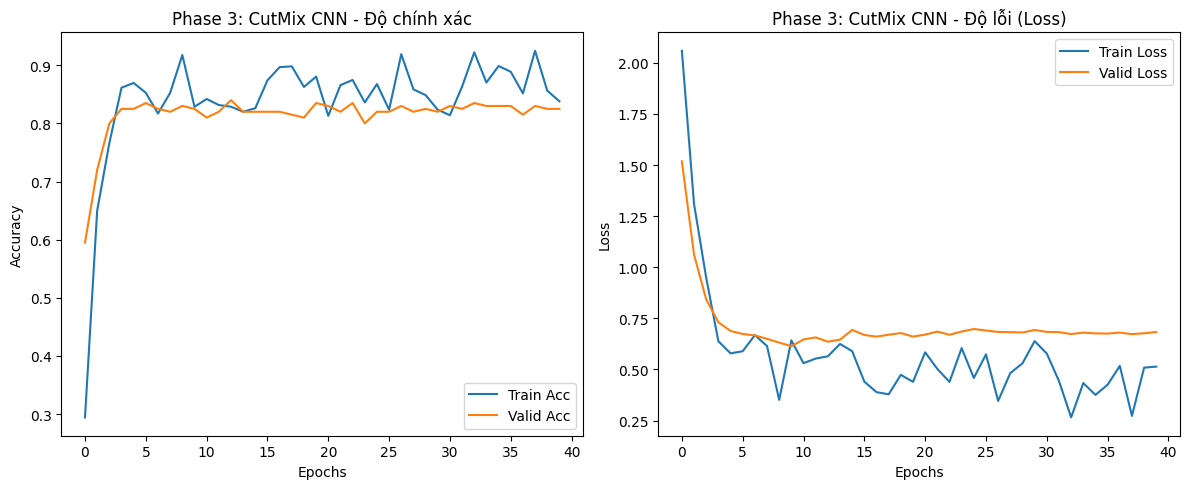

In [3]:

# ==========================================
# BƯỚC 2 : HÀM CUTMIX
# ==========================================
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

# 2. Xác định đường dẫn tới 3 thư mục
train_dir = os.path.join(dataset_path, "Fast Food Classification V2/Train")
valid_dir = os.path.join(dataset_path, "Fast Food Classification V2/Valid")
test_dir = os.path.join(dataset_path, "Fast Food Classification V2/Test")

# 3. Tiền xử lý ảnh (Resize và chuẩn hóa màu)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Tải TOÀN BỘ ảnh lên
train_data = datasets.ImageFolder(train_dir, transform=transform)
valid_data = datasets.ImageFolder(valid_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)

# 5. BỐC THĂM lấy ngẫu nhiên 800 Train, 200 Valid, 200 Test
train_indices = torch.randperm(len(train_data))[:800]
valid_indices = torch.randperm(len(valid_data))[:200]
test_indices = torch.randperm(len(test_data))[:200]

# 6. Tạo TẬP CON (Subset) từ danh sách bốc thăm
train_subset = Subset(train_data, train_indices)
valid_subset = Subset(valid_data, valid_indices)
test_subset = Subset(test_data, test_indices)

# 7. Đưa vào đường ống DataLoader
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_subset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=2)

print(f"2. Đã rút gọn xong! Số lượng đang dùng -> Train: {len(train_subset)} | Valid: {len(valid_subset)} | Test: {len(test_subset)}")

# ==========================================
# BƯỚC 3: MÔ HÌNH RESNET18 & TỐI ƯU HÓA
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(train_data.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# 1. GIẢM Learning Rate xuống 20 lần (5e-5) để AI học chậm, chắc hơn
# TĂNG Weight Decay lên 50 lần (5e-3) để hiệu chỉnh weights chặt chẽ, chống Overfitting
optimizer = optim.Adam(model.parameters(), lr=0.00005, weight_decay=5e-3)

# 2. THÊM Scheduler để từ từ bóp nhỏ Learning Rate qua từng Epoch (ổn định)
from torch.optim.lr_scheduler import CosineAnnealingLR

epochs = 40
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

# ==========================================
# BƯỚC 4: HUẤN LUYỆN KÈM VALIDATION VÀ VẼ BIỂU ĐỒ
# ==========================================
beta = 1.0
cutmix_prob = 0.5

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

print("4. Bắt đầu huấn luyện và đánh giá (CutMix) - Tối ưu hóa mượt mà...\n")
for epoch in range(epochs):
    # --- PHA 1: HUẤN LUYỆN (TRAINING) ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        r = np.random.rand(1)

        if beta > 0 and r < cutmix_prob:
            lam = np.random.beta(beta, beta)
            rand_index = torch.randperm(inputs.size()[0]).to(device)

            target_a = targets
            target_b = targets[rand_index]

            bbx1, bby1, bbx2, bby2 = rand_bbox(inputs.size(), lam)
            inputs[:, :, bbx1:bbx2, bby1:bby2] = inputs[rand_index, :, bbx1:bbx2, bby1:bby2]
            lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (inputs.size()[-1] * inputs.size()[-2]))

            outputs = model(inputs)
            loss = criterion(outputs, target_a) * lam + criterion(outputs, target_b) * (1. - lam)
            _, predicted = outputs.max(1)
            acc_tensor = (predicted.eq(target_a).float() * lam + predicted.eq(target_b).float() * (1. - lam))
            correct_train += acc_tensor.sum().item()

        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            _, predicted = outputs.max(1)
            correct_train += predicted.eq(targets).sum().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_train += targets.size(0)

    # Tính trung bình Loss và Accuracy của Train
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- PHA 2: ĐÁNH GIÁ  ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_targets in valid_loader:
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)

            val_outputs = model(val_inputs)
            loss = criterion(val_outputs, val_targets)

            val_loss += loss.item()
            _, predicted = val_outputs.max(1)
            total_val += val_targets.size(0)
            correct_val += predicted.eq(val_targets).sum().item()

    epoch_val_loss = val_loss / len(valid_loader)
    epoch_val_acc = correct_val / total_val
    valid_losses.append(epoch_val_loss)
    valid_accs.append(epoch_val_acc)

    # Cập nhật Scheduler sau mỗi Epoch để từ từ bóp LR
    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | Valid Loss: {epoch_val_loss:.4f}, Valid Acc: {epoch_val_acc:.4f}")

# ==========================================
# BƯỚC 5: VẼ BIỂU ĐỒ VÀ LƯU MÔ HÌNH
# ==========================================
print("\nĐang vẽ biểu đồ...")

# Tạo một khung hình chứa 2 biểu đồ nằm ngang (1 hàng, 2 cột)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: Độ chính xác (Accuracy)
ax1.plot(train_accs, label='Train Acc', color='tab:blue')
ax1.plot(valid_accs, label='Valid Acc', color='tab:orange')
ax1.set_title('Phase 3: CutMix CNN - Độ chính xác')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Biểu đồ 2: Độ lỗi (Loss)
ax2.plot(train_losses, label='Train Loss', color='tab:blue')
ax2.plot(valid_losses, label='Valid Loss', color='tab:orange')
ax2.set_title('Phase 3: CutMix CNN - Độ lỗi (Loss)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

# Hiển thị biểu đồ ra màn hình
plt.tight_layout()
plt.show()

In [4]:
# Lưu trọng số của mô hình thành file .pth
torch.save(model.state_dict(), 'AI_FastFood_CutMix1.pth')
print("Đã lưu bộ não AI thành công vào file AI_FastFood_CutMix1.pth!")

Đã lưu bộ não AI thành công vào file AI_FastFood_CutMix1.pth!
